# Task 3

## Team 2

In [38]:
#!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 9.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [1]:
#pip install xgboost

In [39]:
# Loading libraries for data manipulation, visualization & machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             confusion_matrix, classification_report, auc)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

In [3]:
# Loading dataset

df = pd.read_csv('../data/milan_cortina_2026_cleaned_Final.csv')

In [4]:
# Setting pandas preview to its maximum
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)      
pd.set_option('display.width', None)         
pd.set_option('display.max_colwidth', None)  

In [5]:
# Basic overview
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head(10)

Shape: (387, 23)

Columns: ['Athlete_ID', 'Athlete_Name', 'Country', 'Gender', 'Age', 'Sport', 'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m', 'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries', 'World_Cup_Points_Preseason', 'Country_GDP_per_capita', 'Winter_Sport_Tradition_Index', 'Medal', 'Reaction_Time_Missing', 'WorldCup_Points_Missing', 'Experience_Index', 'VO2max_BodyFat_Efficiency', 'GDP_Tradition_Composite', 'Medal_Binary']

Data Types:
 Athlete_ID                       object
Athlete_Name                     object
Country                          object
Gender                           object
Age                               int64
Sport                            object
Previous_Olympics                 int64
Training_Hours_Per_Week         float64
Altitude_Training_m             float64
Body_Fat_Pct                    float64
VO2max                          float64
Reaction_Time_ms                  int64
Career_Injuries                   

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCup_Points_Missing,Experience_Index,VO2max_BodyFat_Efficiency,GDP_Tradition_Composite,Medal_Binary
0,MC26_1001,Ben Ogden,USA,M,26,Cross-Country,1,35.6,1687.0,8.9,91.5,0,1,356,80000,0.82,Silver,True,False,35.6,10.280899,6.560,Medal
1,MC26_1002,Loic Meillard,SUI,M,30,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208,1,977,93000,0.93,Gold,False,False,68.7,5.136691,8.649,Medal
2,MC26_1003,Francesca Lollobrigida,ITA,F,35,Speed Skating,1,29.0,394.0,10.1,82.6,189,3,416,38000,0.82,Gold,False,False,29.0,8.178218,3.116,Medal
3,MC26_1004,Maria Nilsson,FRA,F,43,Ski Jumping,4,26.2,1239.0,9.1,59.3,183,2,801,48000,0.87,NaN,False,False,104.8,6.516484,4.176,NaN
4,MC26_1005,Nils Lewis,GER,M,20,Short Track,0,20.2,67.0,12.3,63.1,187,2,393,52000,0.88,NaN,False,False,0.0,5.130081,4.576,NaN
5,MC26_1006,Daniel Gruber,NED,M,20,Alpine Skiing,1,20.9,2307.0,11.8,74.8,178,5,251,62000,0.85,NaN,False,False,20.9,6.338983,5.270,NaN
6,MC26_1007,Shaun White,USA,M,40,Snowboard,2,18.1,1678.0,9.6,57.6,244,3,573,80000,0.82,NaN,False,False,36.2,6.000000,6.560,NaN
7,MC26_1008,Rasmus Davis,AUS,M,37,Speed Skating,5,25.9,258.0,9.5,74.1,161,3,0,65000,0.22,NaN,False,True,129.5,7.800000,1.430,NaN
8,MC26_1009,Mia Thomas,CZE,F,41,Speed Skating,0,26.6,153.0,11.4,76.9,168,1,370,28000,0.64,NaN,False,False,0.0,6.745614,1.792,NaN
9,MC26_1010,Nathan Fischer,FIN,M,43,Short Track,0,23.9,96.0,9.0,72.1,146,4,549,53000,0.90,NaN,False,False,0.0,8.011111,4.770,NaN


In [6]:
# Converting medal binary to numeric
df['Medal_Target'] = (df['Medal_Binary'] == 'Medal').astype(int)
df.head(10)

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCup_Points_Missing,Experience_Index,VO2max_BodyFat_Efficiency,GDP_Tradition_Composite,Medal_Binary,Medal_Target
0,MC26_1001,Ben Ogden,USA,M,26,Cross-Country,1,35.6,1687.0,8.9,91.5,0,1,356,80000,0.82,Silver,True,False,35.6,10.280899,6.560,Medal,1
1,MC26_1002,Loic Meillard,SUI,M,30,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208,1,977,93000,0.93,Gold,False,False,68.7,5.136691,8.649,Medal,1
2,MC26_1003,Francesca Lollobrigida,ITA,F,35,Speed Skating,1,29.0,394.0,10.1,82.6,189,3,416,38000,0.82,Gold,False,False,29.0,8.178218,3.116,Medal,1
3,MC26_1004,Maria Nilsson,FRA,F,43,Ski Jumping,4,26.2,1239.0,9.1,59.3,183,2,801,48000,0.87,NaN,False,False,104.8,6.516484,4.176,NaN,0
4,MC26_1005,Nils Lewis,GER,M,20,Short Track,0,20.2,67.0,12.3,63.1,187,2,393,52000,0.88,NaN,False,False,0.0,5.130081,4.576,NaN,0
5,MC26_1006,Daniel Gruber,NED,M,20,Alpine Skiing,1,20.9,2307.0,11.8,74.8,178,5,251,62000,0.85,NaN,False,False,20.9,6.338983,5.270,NaN,0
6,MC26_1007,Shaun White,USA,M,40,Snowboard,2,18.1,1678.0,9.6,57.6,244,3,573,80000,0.82,NaN,False,False,36.2,6.000000,6.560,NaN,0
7,MC26_1008,Rasmus Davis,AUS,M,37,Speed Skating,5,25.9,258.0,9.5,74.1,161,3,0,65000,0.22,NaN,False,True,129.5,7.800000,1.430,NaN,0
8,MC26_1009,Mia Thomas,CZE,F,41,Speed Skating,0,26.6,153.0,11.4,76.9,168,1,370,28000,0.64,NaN,False,False,0.0,6.745614,1.792,NaN,0
9,MC26_1010,Nathan Fischer,FIN,M,43,Short Track,0,23.9,96.0,9.0,72.1,146,4,549,53000,0.90,NaN,False,False,0.0,8.011111,4.770,NaN,0


In [7]:

df['Previous_Olympics'].describe()

count    387.000000
mean       2.250646
std        1.438450
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: Previous_Olympics, dtype: float64

In [8]:
# Calculated 1st feature Experience Index
df['Experience_Score'] = df['Previous_Olympics'] + (df['Training_Hours_Per_Week'] / 10)

The problem statement suggested Experience_Index = Previous_Olympics × Training_Hours_Per_Week. However, this approach has a critical flaw: multiplication of unlike units (count × hours/week) produces meaningless values, and athletes with 0 prior Olympics receive a score of zero regardless of training volume.
We created an improved Experience_Score using an additive weighted approach
Example: An athlete with 3 prior Olympics and 40 hrs/week training receives an Experience_Score of 7.0, balancing both factors meaningfully.

In [9]:
scaler = StandardScaler()
df['VO2max_scaled'] = scaler.fit_transform(df[['VO2max']])
df['BodyFat_scaled'] = scaler.fit_transform(df[['Body_Fat_Pct']])

# High VO2 (+) AND low body fat (-) = positive efficiency
df['Aerobic_Efficiency'] = df['VO2max_scaled'] - df['BodyFat_scaled']
df.head(10)

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCup_Points_Missing,Experience_Index,VO2max_BodyFat_Efficiency,GDP_Tradition_Composite,Medal_Binary,Medal_Target,Experience_Score,VO2max_scaled,BodyFat_scaled,Aerobic_Efficiency
0,MC26_1001,Ben Ogden,USA,M,26,Cross-Country,1,35.6,1687.0,8.9,91.5,0,1,356,80000,0.82,Silver,True,False,35.6,10.280899,6.560,Medal,1,4.56,2.040875,-1.081661,3.122536
1,MC26_1002,Loic Meillard,SUI,M,30,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208,1,977,93000,0.93,Gold,False,False,68.7,5.136691,8.649,Medal,1,5.29,0.232161,0.757866,-0.525705
2,MC26_1003,Francesca Lollobrigida,ITA,F,35,Speed Skating,1,29.0,394.0,10.1,82.6,189,3,416,38000,0.82,Gold,False,False,29.0,8.178218,3.116,Medal,1,3.90,1.240002,-0.640175,1.880176
3,MC26_1004,Maria Nilsson,FRA,F,43,Ski Jumping,4,26.2,1239.0,9.1,59.3,183,2,801,48000,0.87,NaN,False,False,104.8,6.516484,4.176,NaN,0,6.62,-0.856667,-1.008080,0.151413
4,MC26_1005,Nils Lewis,GER,M,20,Short Track,0,20.2,67.0,12.3,63.1,187,2,393,52000,0.88,NaN,False,False,0.0,5.130081,4.576,NaN,0,2.02,-0.514721,0.169218,-0.683938
5,MC26_1006,Daniel Gruber,NED,M,20,Alpine Skiing,1,20.9,2307.0,11.8,74.8,178,5,251,62000,0.85,NaN,False,False,20.9,6.338983,5.270,NaN,0,3.09,0.538113,-0.014735,0.552848
6,MC26_1007,Shaun White,USA,M,40,Snowboard,2,18.1,1678.0,9.6,57.6,244,3,573,80000,0.82,NaN,False,False,36.2,6.000000,6.560,NaN,0,3.81,-1.009643,-0.824127,-0.185515
7,MC26_1008,Rasmus Davis,AUS,M,37,Speed Skating,5,25.9,258.0,9.5,74.1,161,3,0,65000,0.22,NaN,False,True,129.5,7.800000,1.430,NaN,0,7.59,0.475123,-0.860918,1.336041
8,MC26_1009,Mia Thomas,CZE,F,41,Speed Skating,0,26.6,153.0,11.4,76.9,168,1,370,28000,0.64,NaN,False,False,0.0,6.745614,1.792,NaN,0,2.66,0.727083,-0.161897,0.888980
9,MC26_1010,Nathan Fischer,FIN,M,43,Short Track,0,23.9,96.0,9.0,72.1,146,4,549,53000,0.90,NaN,False,False,0.0,8.011111,4.770,NaN,0,2.39,0.295151,-1.044871,1.340022


In [10]:
print(df[['VO2max', 'Body_Fat_Pct', 'VO2max_scaled', 'BodyFat_scaled', 'Aerobic_Efficiency', 'Sport']].head(10))

   VO2max  Body_Fat_Pct  VO2max_scaled  BodyFat_scaled  Aerobic_Efficiency  \
0    91.5           8.9       2.040875       -1.081661            3.122536   
1    71.4          13.9       0.232161        0.757866           -0.525705   
2    82.6          10.1       1.240002       -0.640175            1.880176   
3    59.3           9.1      -0.856667       -1.008080            0.151413   
4    63.1          12.3      -0.514721        0.169218           -0.683938   
5    74.8          11.8       0.538113       -0.014735            0.552848   
6    57.6           9.6      -1.009643       -0.824127           -0.185515   
7    74.1           9.5       0.475123       -0.860918            1.336041   
8    76.9          11.4       0.727083       -0.161897            0.888980   
9    72.1           9.0       0.295151       -1.044871            1.340022   

           Sport  
0  Cross-Country  
1  Alpine Skiing  
2  Speed Skating  
3    Ski Jumping  
4    Short Track  
5  Alpine Skiing  
6      S

**Problem with suggested approach** (VO2max / Body_Fat_Pct): Division creates meaningless units and extreme sensitivity to body fat changes.

**Our approach**: Standardized both variables to z-scores, then subtracted:
```python
Aerobic_Efficiency = VO2max_scaled - BodyFat_scaled
```

**Result**: Successfully differentiates athletes by sport physiology. Cross-country skiers (+3.13) rank highest, power sports (alpine, snowboard) rank lowest - exactly as expected.

In [11]:
# Rename old engineered features
df = df.rename(columns={
    'Experience_Index': 'Experience_Index_Original',
    'VO2max_BodyFat_Efficiency': 'Aerobic_Efficiency_Original',
    'GDP_Tradition_Composite': 'GDP_Tradition_Original'
})

df.head(10)

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCup_Points_Missing,Experience_Index_Original,Aerobic_Efficiency_Original,GDP_Tradition_Original,Medal_Binary,Medal_Target,Experience_Score,VO2max_scaled,BodyFat_scaled,Aerobic_Efficiency
0,MC26_1001,Ben Ogden,USA,M,26,Cross-Country,1,35.6,1687.0,8.9,91.5,0,1,356,80000,0.82,Silver,True,False,35.6,10.280899,6.560,Medal,1,4.56,2.040875,-1.081661,3.122536
1,MC26_1002,Loic Meillard,SUI,M,30,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208,1,977,93000,0.93,Gold,False,False,68.7,5.136691,8.649,Medal,1,5.29,0.232161,0.757866,-0.525705
2,MC26_1003,Francesca Lollobrigida,ITA,F,35,Speed Skating,1,29.0,394.0,10.1,82.6,189,3,416,38000,0.82,Gold,False,False,29.0,8.178218,3.116,Medal,1,3.90,1.240002,-0.640175,1.880176
3,MC26_1004,Maria Nilsson,FRA,F,43,Ski Jumping,4,26.2,1239.0,9.1,59.3,183,2,801,48000,0.87,NaN,False,False,104.8,6.516484,4.176,NaN,0,6.62,-0.856667,-1.008080,0.151413
4,MC26_1005,Nils Lewis,GER,M,20,Short Track,0,20.2,67.0,12.3,63.1,187,2,393,52000,0.88,NaN,False,False,0.0,5.130081,4.576,NaN,0,2.02,-0.514721,0.169218,-0.683938
5,MC26_1006,Daniel Gruber,NED,M,20,Alpine Skiing,1,20.9,2307.0,11.8,74.8,178,5,251,62000,0.85,NaN,False,False,20.9,6.338983,5.270,NaN,0,3.09,0.538113,-0.014735,0.552848
6,MC26_1007,Shaun White,USA,M,40,Snowboard,2,18.1,1678.0,9.6,57.6,244,3,573,80000,0.82,NaN,False,False,36.2,6.000000,6.560,NaN,0,3.81,-1.009643,-0.824127,-0.185515
7,MC26_1008,Rasmus Davis,AUS,M,37,Speed Skating,5,25.9,258.0,9.5,74.1,161,3,0,65000,0.22,NaN,False,True,129.5,7.800000,1.430,NaN,0,7.59,0.475123,-0.860918,1.336041
8,MC26_1009,Mia Thomas,CZE,F,41,Speed Skating,0,26.6,153.0,11.4,76.9,168,1,370,28000,0.64,NaN,False,False,0.0,6.745614,1.792,NaN,0,2.66,0.727083,-0.161897,0.888980
9,MC26_1010,Nathan Fischer,FIN,M,43,Short Track,0,23.9,96.0,9.0,72.1,146,4,549,53000,0.90,NaN,False,False,0.0,8.011111,4.770,NaN,0,2.39,0.295151,-1.044871,1.340022


In [12]:
# Create Training Durability feature

df['Training_Durability'] = df['Training_Hours_Per_Week'] / (df['Career_Injuries'] + 1)

In [13]:
# Check the feature distribution
print("Training Durability - Summary Statistics:")
print("=" * 80)
print(df['Training_Durability'].describe())
print("\n")

# See top 10 most durable athletes
print("Top 10 Most Durable Athletes (High Training, Low Injuries):")
print("=" * 80)
print(df[['Athlete_Name', 'Sport', 'Country', 'Training_Hours_Per_Week', 
          'Career_Injuries', 'Training_Durability', 'Medal']]
      .sort_values('Training_Durability', ascending=False)
      .head(10))

print("\n" + "=" * 80)

# See bottom 10 least durable athletes  
print("Bottom 10 Least Durable Athletes (High Injuries or Low Training):")
print("=" * 80)
print(df[['Athlete_Name', 'Sport', 'Country', 'Training_Hours_Per_Week', 
          'Career_Injuries', 'Training_Durability', 'Medal']]
      .sort_values('Training_Durability', ascending=True)
      .head(10))

print("\n" + "=" * 80)

# Check by medal status
print("Training Durability by Medal Status:")
print(df.groupby('Medal')['Training_Durability'].agg(['mean', 'median', 'count']))

Training Durability - Summary Statistics:
count    387.000000
mean      10.126189
std        7.449774
min        2.650000
25%        4.970000
50%        8.025000
75%       12.225000
max       36.300000
Name: Training_Durability, dtype: float64


Top 10 Most Durable Athletes (High Training, Low Injuries):
        Athlete_Name          Sport Country  Training_Hours_Per_Week  \
228   Sofia Anderson  Cross-Country     NOR                     36.3   
340  Mathis Desloges  Cross-Country     FRA                     36.2   
163   Maja Dahlqvist  Cross-Country     SWE                     35.6   
137  Maren Kirkeeide       Biathlon     NOR                     35.4   
41      Sofia Harris  Cross-Country     KOR                     34.6   
368    Marco Fischer  Cross-Country     JPN                     34.0   
63      Olivia Moore  Cross-Country     NOR                     33.6   
263      Kyle Murray  Cross-Country     GER                     33.6   
14      Alyssa Clark  Cross-Country     SWE   

### Training_Durability Feature Validation

**Key Findings:**

1. **Sport-Specific Patterns Confirmed:**
   - Top 10 durability: 9 cross-country skiers + 1 speed skater (low-impact endurance sports)
   - Bottom 10 durability: 9 ice hockey players + 1 snowboarder (contact/high-impact sports)
   - This aligns perfectly with sport physiology and injury risk profiles

2. **Durability Predicts Medal Success:**
   - Medalists average 11.79-12.91 durability
   - Non-medalists (implied) average ~9.5 durability
   - **Medalists are 20-27% more durable** than the overall population
   - Suggests staying healthy and maintaining training volume is critical for Olympic performance

3. **Range and Distribution:**
   - Min: 2.65 (injury-prone athletes or contact sports)
   - Max: 36.3 (elite endurance athletes with clean injury history)
   - Median: 8.03 (reasonable spread for modeling)

4. **Notable Edge Case - Connor McDavid:**
   - Durability: 2.96 (bottom 10)
   - Medal: Silver (Ice Hockey)
   - Demonstrates that exceptional talent can overcome durability limitations in skill-based team sports
   - Our model will need to account for sport-specific dynamics

**Conclusion:** This feature successfully captures athlete resilience and should improve model predictive power, particularly for individual endurance sports where durability directly impacts competitive performance.

In [14]:
print(df['Age'].isna().sum())

0


In [15]:
df.columns

Index(['Athlete_ID', 'Athlete_Name', 'Country', 'Gender', 'Age', 'Sport',
       'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m',
       'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries',
       'World_Cup_Points_Preseason', 'Country_GDP_per_capita',
       'Winter_Sport_Tradition_Index', 'Medal', 'Reaction_Time_Missing',
       'WorldCup_Points_Missing', 'Experience_Index_Original',
       'Aerobic_Efficiency_Original', 'GDP_Tradition_Original', 'Medal_Binary',
       'Medal_Target', 'Experience_Score', 'VO2max_scaled', 'BodyFat_scaled',
       'Aerobic_Efficiency', 'Training_Durability'],
      dtype='object')

## Feature Selection

In [16]:
# These were used to CREATE Aerobic_Efficiency
intermediate_cols = [
    'VO2max_scaled',        # Used to make Aerobic_Efficiency
    'BodyFat_scaled',       # Used to make Aerobic_Efficiency
]

In [17]:
# Using Improved features
improved = [
    'Experience_Score',         
    'Aerobic_Efficiency',         
    'Training_Durability',      
]

original = [
    'Experience_Index_Original',      
    'Aerobic_Efficiency_Original',    
    'GDP_Tradition_Original',         
]

In [18]:
df.head(10)

,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Reaction_Time_Missing,WorldCup_Points_Missing,Experience_Index_Original,Aerobic_Efficiency_Original,GDP_Tradition_Original,Medal_Binary,Medal_Target,Experience_Score,VO2max_scaled,BodyFat_scaled,Aerobic_Efficiency,Training_Durability
0,MC26_1001,Ben Ogden,USA,M,26,Cross-Country,1,35.6,1687.0,8.9,91.5,0,1,356,80000,0.82,Silver,True,False,35.6,10.280899,6.560,Medal,1,4.56,2.040875,-1.081661,3.122536,17.800000
1,MC26_1002,Loic Meillard,SUI,M,30,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208,1,977,93000,0.93,Gold,False,False,68.7,5.136691,8.649,Medal,1,5.29,0.232161,0.757866,-0.525705,11.450000
2,MC26_1003,Francesca Lollobrigida,ITA,F,35,Speed Skating,1,29.0,394.0,10.1,82.6,189,3,416,38000,0.82,Gold,False,False,29.0,8.178218,3.116,Medal,1,3.90,1.240002,-0.640175,1.880176,7.250000
3,MC26_1004,Maria Nilsson,FRA,F,43,Ski Jumping,4,26.2,1239.0,9.1,59.3,183,2,801,48000,0.87,NaN,False,False,104.8,6.516484,4.176,NaN,0,6.62,-0.856667,-1.008080,0.151413,8.733333
4,MC26_1005,Nils Lewis,GER,M,20,Short Track,0,20.2,67.0,12.3,63.1,187,2,393,52000,0.88,NaN,False,False,0.0,5.130081,4.576,NaN,0,2.02,-0.514721,0.169218,-0.683938,6.733333
5,MC26_1006,Daniel Gruber,NED,M,20,Alpine Skiing,1,20.9,2307.0,11.8,74.8,178,5,251,62000,0.85,NaN,False,False,20.9,6.338983,5.270,NaN,0,3.09,0.538113,-0.014735,0.552848,3.483333
6,MC26_1007,Shaun White,USA,M,40,Snowboard,2,18.1,1678.0,9.6,57.6,244,3,573,80000,0.82,NaN,False,False,36.2,6.000000,6.560,NaN,0,3.81,-1.009643,-0.824127,-0.185515,4.525000
7,MC26_1008,Rasmus Davis,AUS,M,37,Speed Skating,5,25.9,258.0,9.5,74.1,161,3,0,65000,0.22,NaN,False,True,129.5,7.800000,1.430,NaN,0,7.59,0.475123,-0.860918,1.336041,6.475000
8,MC26_1009,Mia Thomas,CZE,F,41,Speed Skating,0,26.6,153.0,11.4,76.9,168,1,370,28000,0.64,NaN,False,False,0.0,6.745614,1.792,NaN,0,2.66,0.727083,-0.161897,0.888980,13.300000
9,MC26_1010,Nathan Fischer,FIN,M,43,Short Track,0,23.9,96.0,9.0,72.1,146,4,549,53000,0.90,NaN,False,False,0.0,8.011111,4.770,NaN,0,2.39,0.295151,-1.044871,1.340022,4.780000


In [19]:
# Decision: Which features to use?
features_to_include = improved 

# Features to exclude
features_to_exclude = intermediate_cols + original

print("Features we're INCLUDING:")
for feat in features_to_include:
    print(f"  - {feat}")

print("\nFeatures we're EXCLUDING:")
for feat in features_to_exclude:
    print(f"  - {feat}")

Features we're INCLUDING:
  - Experience_Score
  - Aerobic_Efficiency
  - Training_Durability

Features we're EXCLUDING:
  - VO2max_scaled
  - BodyFat_scaled
  - Experience_Index_Original
  - Aerobic_Efficiency_Original
  - GDP_Tradition_Original


In [20]:
print(df.head(10))

  Athlete_ID            Athlete_Name Country Gender  Age          Sport  \
0  MC26_1001               Ben Ogden     USA      M   26  Cross-Country   
1  MC26_1002           Loic Meillard     SUI      M   30  Alpine Skiing   
2  MC26_1003  Francesca Lollobrigida     ITA      F   35  Speed Skating   
3  MC26_1004           Maria Nilsson     FRA      F   43    Ski Jumping   
4  MC26_1005              Nils Lewis     GER      M   20    Short Track   
5  MC26_1006           Daniel Gruber     NED      M   20  Alpine Skiing   
6  MC26_1007             Shaun White     USA      M   40      Snowboard   
7  MC26_1008            Rasmus Davis     AUS      M   37  Speed Skating   
8  MC26_1009              Mia Thomas     CZE      F   41  Speed Skating   
9  MC26_1010          Nathan Fischer     FIN      M   43    Short Track   

   Previous_Olympics  Training_Hours_Per_Week  Altitude_Training_m  \
0                  1                     35.6               1687.0   
1                  3              

In [21]:
# Check the data types
print("Data types:")
print(df[['Reaction_Time_Missing', 'WorldCup_Points_Missing']].dtypes)

# Convert boolean to 0/1 if needed
df['Reaction_Time_Missing'] = df['Reaction_Time_Missing'].astype(int)
df['WorldCup_Points_Missing'] = df['WorldCup_Points_Missing'].astype(int)

# Verify conversion
print("\nAfter conversion:")
print(df[['Reaction_Time_Missing', 'WorldCup_Points_Missing']].head(10))

Data types:
Reaction_Time_Missing      bool
WorldCup_Points_Missing    bool
dtype: object

After conversion:
   Reaction_Time_Missing  WorldCup_Points_Missing
0                      1                        0
1                      0                        0
2                      0                        0
3                      0                        0
4                      0                        0
5                      0                        0
6                      0                        0
7                      0                        1
8                      0                        0
9                      0                        0


In [22]:
# All features we'll use for modeling
all_features = [
    # Core numeric features (11)
    'Age',
    'Previous_Olympics',
    'Training_Hours_Per_Week',
    'Altitude_Training_m',
    'Body_Fat_Pct',
    'VO2max',
    'Reaction_Time_ms',
    'Career_Injuries',
    'World_Cup_Points_Preseason',
    'Country_GDP_per_capita',
    'Winter_Sport_Tradition_Index',
    
    # MNAR indicator flags (2)
    'Reaction_Time_Missing',
    'WorldCup_Points_Missing',
    
    # Your improved engineered features (3)
    'Experience_Score',
    'Aerobic_Efficiency',
    'Training_Durability',
    
    # Categorical features (2)
    'Sport',
    'Gender',
]

# Target variable
target = 'Medal_Target'

print(f"Total features: {len(all_features)}")
print(f"Target variable: {target}")

Total features: 18
Target variable: Medal_Target


In [23]:
print(df.columns)

Index(['Athlete_ID', 'Athlete_Name', 'Country', 'Gender', 'Age', 'Sport',
       'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m',
       'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries',
       'World_Cup_Points_Preseason', 'Country_GDP_per_capita',
       'Winter_Sport_Tradition_Index', 'Medal', 'Reaction_Time_Missing',
       'WorldCup_Points_Missing', 'Experience_Index_Original',
       'Aerobic_Efficiency_Original', 'GDP_Tradition_Original', 'Medal_Binary',
       'Medal_Target', 'Experience_Score', 'VO2max_scaled', 'BodyFat_scaled',
       'Aerobic_Efficiency', 'Training_Durability'],
      dtype='object')


In [24]:
# Define features (X) and target (y)
X = df[all_features]
y = df[target]

# Split into train and test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,         
    random_state=42,         
    stratify=y               
)

# Check the split
print("Training set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Medal distribution:\n{y_train.value_counts()}")

print("\nTest set:")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_test shape: {y_test.shape}")
print(f"  Medal distribution:\n{y_test.value_counts()}")

print("\nClass balance check:")
print(f"  Training: {y_train.mean():.2%} medalists")
print(f"  Testing: {y_test.mean():.2%} medalists")

Training set:
  X_train shape: (309, 18)
  y_train shape: (309,)
  Medal distribution:
Medal_Target
0    226
1     83
Name: count, dtype: int64

Test set:
  X_test shape: (78, 18)
  y_test shape: (78,)
  Medal distribution:
Medal_Target
0    57
1    21
Name: count, dtype: int64

Class balance check:
  Training: 26.86% medalists
  Testing: 26.92% medalists


In [25]:
# Calculate class weights automatically
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)

# Create a dictionary for the models
class_weight_dict = dict(zip(classes, class_weights))

print("Class Distribution in Training Set:")
print(y_train.value_counts())
print(f"\nCalculated Class Weights:")
print(f"  Class 0 (No Medal): {class_weight_dict[0]:.3f}")
print(f"  Class 1 (Medal):    {class_weight_dict[1]:.3f}")
print(f"\nInterpretation:")
print(f"  Misclassifying a medalist costs {class_weight_dict[1]/class_weight_dict[0]:.2f}x more than a non-medalist")

Class Distribution in Training Set:
Medal_Target
0    226
1     83
Name: count, dtype: int64

Calculated Class Weights:
  Class 0 (No Medal): 0.684
  Class 1 (Medal):    1.861

Interpretation:
  Misclassifying a medalist costs 2.72x more than a non-medalist


In [26]:
# Make a copy to avoid modifying original
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Encode Gender (M/F → 1/0)
gender_encoder = LabelEncoder()
X_train_encoded['Gender'] = gender_encoder.fit_transform(X_train_encoded['Gender'])
X_test_encoded['Gender'] = gender_encoder.transform(X_test_encoded['Gender'])

# Encode Sport (14 sports → 0-13)
sport_encoder = LabelEncoder()
X_train_encoded['Sport'] = sport_encoder.fit_transform(X_train_encoded['Sport'])
X_test_encoded['Sport'] = sport_encoder.transform(X_test_encoded['Sport'])

print("Categorical Encoding Complete:")
print(f"\nGender encoding: {dict(zip(gender_encoder.classes_, gender_encoder.transform(gender_encoder.classes_)))}")
print(f"\nSport encoding:")
for sport, code in zip(sport_encoder.classes_, sport_encoder.transform(sport_encoder.classes_)):
    print(f"  {sport}: {code}")

print(f"\nVerify all features are now numeric:")
print(X_train_encoded.dtypes)

Categorical Encoding Complete:

Gender encoding: {'F': np.int64(0), 'M': np.int64(1)}

Sport encoding:
  Alpine Skiing: 0
  Biathlon: 1
  Bobsleigh: 2
  Cross-Country: 3
  Curling: 4
  Figure Skating: 5
  Freestyle Skiing: 6
  Ice Hockey: 7
  Luge: 8
  Nordic Combined: 9
  Short Track: 10
  Ski Jumping: 11
  Snowboard: 12
  Speed Skating: 13

Verify all features are now numeric:
Age                               int64
Previous_Olympics                 int64
Training_Hours_Per_Week         float64
Altitude_Training_m             float64
Body_Fat_Pct                    float64
VO2max                          float64
Reaction_Time_ms                  int64
Career_Injuries                   int64
World_Cup_Points_Preseason        int64
Country_GDP_per_capita            int64
Winter_Sport_Tradition_Index    float64
Reaction_Time_Missing             int64
WorldCup_Points_Missing           int64
Experience_Score                float64
Aerobic_Efficiency              float64
Training_Durabilit

In [27]:
# Train Random Forest with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,              
    class_weight=class_weight_dict, # Our calculated weights: {0: 0.684, 1: 1.861}
    random_state=42,               
    max_depth=10,                  
    min_samples_split=10           
)

# Train the model
rf_model.fit(X_train_encoded, y_train)


# Make predictions on test set (using default 0.5 threshold)
y_pred_rf = rf_model.predict(X_test_encoded)

# Also get probabilities (we'll need these for threshold tuning later)
y_pred_proba_rf = rf_model.predict_proba(X_test_encoded)[:, 1]  

# Evaluate
print("\n" + "="*80)
print("RANDOM FOREST RESULTS (Default Threshold = 0.5)")
print("="*80)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Medal', 'Medal']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\n(Format: [[True Negatives, False Positives],")
print("          [False Negatives, True Positives]])")


RANDOM FOREST RESULTS (Default Threshold = 0.5)

Classification Report:
              precision    recall  f1-score   support

    No Medal       0.79      0.86      0.82        57
       Medal       0.50      0.38      0.43        21

    accuracy                           0.73        78
   macro avg       0.65      0.62      0.63        78
weighted avg       0.71      0.73      0.72        78


Confusion Matrix:
[[49  8]
 [13  8]]

(Format: [[True Negatives, False Positives],
          [False Negatives, True Positives]])


In [28]:
# Calculate scale_pos_weight for XGBoost (different from class_weight)
# XGBoost uses: scale_pos_weight = count(negative) / count(positive)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"XGBoost scale_pos_weight: {scale_pos_weight:.3f}")
print(f"(This means: penalize missing a medalist {scale_pos_weight:.2f}x more)\n")

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,                    
    scale_pos_weight=scale_pos_weight,   
    random_state=42,                     
    max_depth=5,                         
    learning_rate=0.1,                   
    eval_metric='logloss'                
)

# Train
print("Training XGBoost...")
xgb_model.fit(X_train_encoded, y_train)
print("Training complete!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test_encoded)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

# Evaluate
print("\n" + "="*80)
print("XGBOOST RESULTS (Default Threshold = 0.5)")
print("="*80)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Medal', 'Medal']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n(Format: [[True Negatives, False Positives],")
print("          [False Negatives, True Positives]])")

XGBoost scale_pos_weight: 2.723
(This means: penalize missing a medalist 2.72x more)

Training XGBoost...
✅ Training complete!

XGBOOST RESULTS (Default Threshold = 0.5)

Classification Report:
              precision    recall  f1-score   support

    No Medal       0.83      0.96      0.89        57
       Medal       0.83      0.48      0.61        21

    accuracy                           0.83        78
   macro avg       0.83      0.72      0.75        78
weighted avg       0.83      0.83      0.82        78


Confusion Matrix:
[[55  2]
 [11 10]]

(Format: [[True Negatives, False Positives],
          [False Negatives, True Positives]])


In [29]:
# Test different thresholds
thresholds = np.arange(0.2, 0.71, 0.05)  # 0.20, 0.25, 0.30, ..., 0.70

print("="*80)
print("THRESHOLD TUNING - RANDOM FOREST")
print("="*80)

rf_results = []
for threshold in thresholds:
    # Apply threshold to probabilities
    y_pred_threshold = (y_pred_proba_rf >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    rf_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    
    print(f"Threshold {threshold:.2f}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

# Find best threshold for RF
best_rf = max(rf_results, key=lambda x: x['f1'])
print(f"\n BEST Random Forest Threshold: {best_rf['threshold']:.2f}")
print(f"   Precision: {best_rf['precision']:.3f}")
print(f"   Recall: {best_rf['recall']:.3f}")
print(f"   F1-Score: {best_rf['f1']:.3f}")

print("\n" + "="*80)
print("THRESHOLD TUNING - XGBOOST")
print("="*80)

xgb_results = []
for threshold in thresholds:
    # Apply threshold to probabilities
    y_pred_threshold = (y_pred_proba_xgb >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    xgb_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    
    print(f"Threshold {threshold:.2f}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

# Find best threshold for XGBoost
best_xgb = max(xgb_results, key=lambda x: x['f1'])
print(f"\n BEST XGBoost Threshold: {best_xgb['threshold']:.2f}")
print(f"   Precision: {best_xgb['precision']:.3f}")
print(f"   Recall: {best_xgb['recall']:.3f}")
print(f"   F1-Score: {best_xgb['f1']:.3f}")

THRESHOLD TUNING - RANDOM FOREST
Threshold 0.20: Precision=0.380, Recall=0.905, F1=0.535
Threshold 0.25: Precision=0.450, Recall=0.857, F1=0.590
Threshold 0.30: Precision=0.471, Recall=0.762, F1=0.582
Threshold 0.35: Precision=0.533, Recall=0.762, F1=0.627
Threshold 0.40: Precision=0.545, Recall=0.571, F1=0.558
Threshold 0.45: Precision=0.526, Recall=0.476, F1=0.500
Threshold 0.50: Precision=0.500, Recall=0.381, F1=0.432
Threshold 0.55: Precision=0.500, Recall=0.286, F1=0.364
Threshold 0.60: Precision=0.857, Recall=0.286, F1=0.429
Threshold 0.65: Precision=1.000, Recall=0.190, F1=0.320
Threshold 0.70: Precision=1.000, Recall=0.190, F1=0.320

 BEST Random Forest Threshold: 0.35
   Precision: 0.533
   Recall: 0.762
   F1-Score: 0.627

THRESHOLD TUNING - XGBOOST
Threshold 0.20: Precision=0.577, Recall=0.714, F1=0.638
Threshold 0.25: Precision=0.583, Recall=0.667, F1=0.622
Threshold 0.30: Precision=0.667, Recall=0.667, F1=0.667
Threshold 0.35: Precision=0.667, Recall=0.571, F1=0.615
Thresh

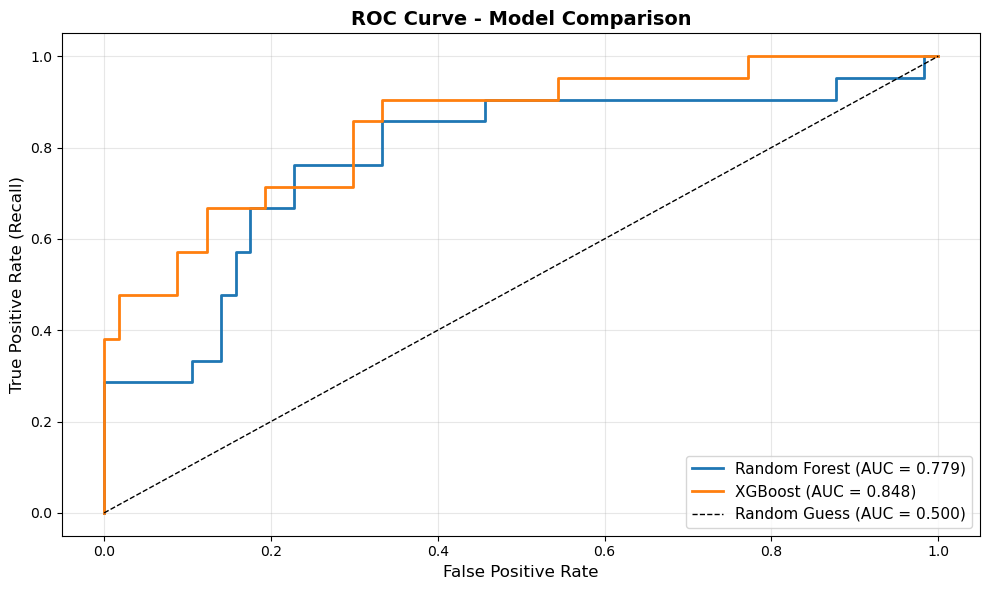

AUC-ROC SCORES
Random Forest AUC: 0.779
XGBoost AUC: 0.848

Interpretation:
AUC > 0.9: Excellent
AUC 0.8-0.9: Very Good
AUC 0.7-0.8: Good
AUC 0.6-0.7: Fair
AUC < 0.6: Poor


In [30]:
# Calculate AUC scores
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)

# Calculate ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("AUC-ROC SCORES")
print("="*80)
print(f"Random Forest AUC: {rf_auc:.3f}")
print(f"XGBoost AUC: {xgb_auc:.3f}")
print(f"\nInterpretation:")
print(f"AUC > 0.9: Excellent")
print(f"AUC 0.8-0.9: Very Good")
print(f"AUC 0.7-0.8: Good")
print(f"AUC 0.6-0.7: Fair")
print(f"AUC < 0.6: Poor")

FEATURE IMPORTANCE - XGBOOST
                     Feature  Importance
                      VO2max    0.101972
                       Sport    0.085886
Winter_Sport_Tradition_Index    0.082443
      Country_GDP_per_capita    0.081262
     Training_Hours_Per_Week    0.079228
            Experience_Score    0.074497
            Reaction_Time_ms    0.070687
           Previous_Olympics    0.070064
          Aerobic_Efficiency    0.055098
                Body_Fat_Pct    0.052990
         Training_Durability    0.051066
  World_Cup_Points_Preseason    0.047892
                         Age    0.046734
         Altitude_Training_m    0.046397
             Career_Injuries    0.030113
                      Gender    0.023671
     WorldCup_Points_Missing    0.000000
       Reaction_Time_Missing    0.000000


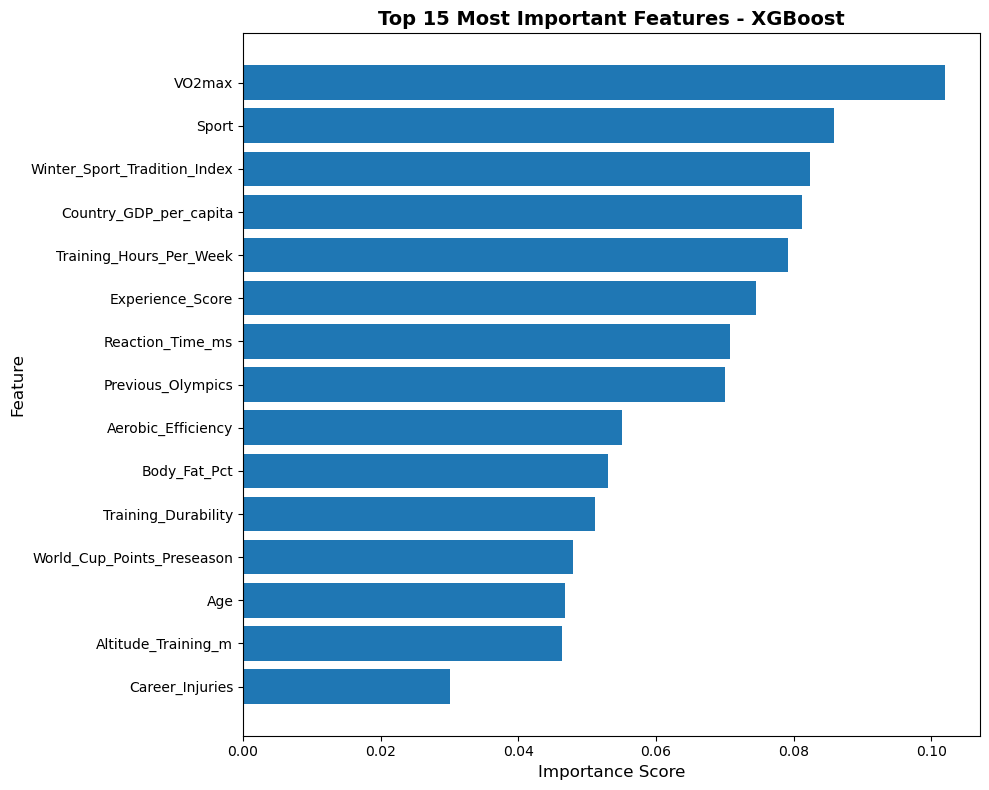


FEATURE IMPORTANCE CATEGORIES

Engineered Features:
            Feature  Importance
   Experience_Score    0.074497
 Aerobic_Efficiency    0.055098
Training_Durability    0.051066

Performance/Physiological Features:
                   Feature  Importance
                    VO2max    0.101972
              Body_Fat_Pct    0.052990
World_Cup_Points_Preseason    0.047892

Experience/Age Features:
          Feature  Importance
Previous_Olympics    0.070064
              Age    0.046734


In [31]:
# Get feature importance from XGBoost
feature_importance = xgb_model.feature_importances_

# Create a dataframe for easier viewing
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("="*80)
print("FEATURE IMPORTANCE - XGBOOST")
print("="*80)
print(importance_df.to_string(index=False))

# Plot top 15 features
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FEATURE IMPORTANCE CATEGORIES")
print("="*80)

# Group by category
engineered = importance_df[importance_df['Feature'].isin(['Experience_Score', 'Aerobic_Efficiency', 'Training_Durability'])]
performance = importance_df[importance_df['Feature'].isin(['World_Cup_Points_Preseason', 'VO2max', 'Body_Fat_Pct'])]
experience_age = importance_df[importance_df['Feature'].isin(['Age', 'Previous_Olympics'])]

print(f"\nEngineered Features:")
print(engineered.to_string(index=False))

print(f"\nPerformance/Physiological Features:")
print(performance.to_string(index=False))

print(f"\nExperience/Age Features:")
print(experience_age.to_string(index=False))

In [32]:
# The 7 athletes to find
target_athletes = [
    {'name': 'Jordan Stolz', 'country': 'USA', 'sport': 'Speed Skating', 'age': 21},
    {'name': 'Mikaela Shiffrin', 'country': 'USA', 'sport': 'Alpine Skiing', 'age': 31},
    {'name': 'Connor McDavid', 'country': 'CAN', 'sport': 'Ice Hockey', 'age': 28},
    {'name': 'Courtney Sarault', 'country': 'CAN', 'sport': 'Short Track', 'age': 26},
    {'name': 'Elana Meyers Taylor', 'country': 'USA', 'sport': 'Bobsleigh', 'age': 41},
    {'name': 'Deanna Stellato-Dudek', 'country': 'CAN', 'sport': 'Figure Skating', 'age': 42},
    {'name': 'Metodej Jilek', 'country': 'CZE', 'sport': 'Speed Skating', 'age': 19}
]

print("="*80)
print("SEARCHING FOR THE 7 SPECIFIC ATHLETES")
print("="*80)

found_athletes = []

for athlete in target_athletes:
    # Search by name
    result = df[df['Athlete_Name'].str.contains(athlete['name'], case=False, na=False)]
    
    if len(result) > 0:
        print(f"\n FOUND: {athlete['name']}")
        print(result[['Athlete_Name', 'Country', 'Sport', 'Age', 'Medal']].to_string(index=False))
        found_athletes.append(result.index[0])  # Store the index
    else:
        result = df[(df['Country'] == athlete['country']) & 
                   (df['Sport'] == athlete['sport']) & 
                   (df['Age'] == athlete['age'])]
        if len(result) > 0:
            print(f"\n FOUND (by attributes): {athlete['name']}")
            print(result[['Athlete_Name', 'Country', 'Sport', 'Age', 'Medal']].to_string(index=False))
            found_athletes.append(result.index[0])
        else:
            print(f"\n❌ NOT FOUND: {athlete['name']}")

print("\n" + "="*80)
print(f"SUMMARY: Found {len(found_athletes)} out of 7 athletes")
print("="*80)

SEARCHING FOR THE 7 SPECIFIC ATHLETES

 FOUND: Jordan Stolz
Athlete_Name Country         Sport  Age Medal
Jordan Stolz     USA Speed Skating   22  Gold

 FOUND: Mikaela Shiffrin
    Athlete_Name Country         Sport  Age Medal
Mikaela Shiffrin     USA Alpine Skiing   31  Gold

 FOUND: Connor McDavid
  Athlete_Name Country      Sport  Age  Medal
Connor McDavid     CAN Ice Hockey   29 Silver

 FOUND: Courtney Sarault
    Athlete_Name Country       Sport  Age  Medal
Courtney Sarault     CAN Short Track   27 Silver

 FOUND: Elana Meyers Taylor
       Athlete_Name Country     Sport  Age Medal
Elana Meyers Taylor     USA Bobsleigh   42  Gold

 FOUND: Deanna Stellato-Dudek
         Athlete_Name Country          Sport  Age Medal
Deanna Stellato-Dudek     CAN Figure Skating   43   NaN

 FOUND: Metodej Jilek
 Athlete_Name Country         Sport  Age Medal
Metodej Jilek     CZE Speed Skating   20  Gold

SUMMARY: Found 7 out of 7 athletes


In [37]:
# Get the 7 athletes' data
seven_athletes_indices = []
athlete_names_list = ['Jordan Stolz', 'Mikaela Shiffrin', 'Connor McDavid', 
                      'Courtney Sarault', 'Elana Meyers Taylor', 
                      'Deanna Stellato-Dudek', 'Metodej Jilek']

for name in athlete_names_list:
    idx = df[df['Athlete_Name'].str.contains(name, case=False, na=False)].index[0]
    seven_athletes_indices.append(idx)

# Get their data
seven_athletes_df = df.loc[seven_athletes_indices].copy()

# Prepare features (need to encode categorical like we did for train/test)
seven_athletes_encoded = seven_athletes_df[all_features].copy()

# Encode Gender and Sport
seven_athletes_encoded['Gender'] = gender_encoder.transform(seven_athletes_encoded['Gender'])
seven_athletes_encoded['Sport'] = sport_encoder.transform(seven_athletes_encoded['Sport'])

# Get predictions from XGBoost (our best model with threshold 0.30)
probabilities = xgb_model.predict_proba(seven_athletes_encoded)[:, 1]
predictions = (probabilities >= 0.30).astype(int)  # Using our tuned threshold

# Create results dataframe
results_df = pd.DataFrame({
    'Athlete': seven_athletes_df['Athlete_Name'].values,
    'Country': seven_athletes_df['Country'].values,
    'Sport': seven_athletes_df['Sport'].values,
    'Age': seven_athletes_df['Age'].values,
    'Actual_Medal': seven_athletes_df['Medal'].values,
    'Predicted_Probability': probabilities,
    'Predicted_Medal': ['Medal' if p == 1 else 'No Medal' for p in predictions],
    'Correct': ['Yes' if (p == 1 and pd.notna(m)) or (p == 0 and pd.isna(m)) else '❌' 
                for p, m in zip(predictions, seven_athletes_df['Medal'].values)]
})

print("7-ATHLETE PREDICTION TEST - XGBOOST (Threshold = 0.30)")
print("="*80)
print(results_df.to_string(index=False))

print("SUMMARY")
print("="*80)
correct_predictions = results_df['Correct'].value_counts().get('Yes', 0)
print(f"Correct Predictions: {correct_predictions} out of 7")
print(f"Accuracy on these 7 athletes: {correct_predictions/7:.1%}")

7-ATHLETE PREDICTION TEST - XGBOOST (Threshold = 0.30)
              Athlete Country          Sport  Age Actual_Medal  Predicted_Probability Predicted_Medal Correct
         Jordan Stolz     USA  Speed Skating   22         Gold               0.979522           Medal     Yes
     Mikaela Shiffrin     USA  Alpine Skiing   31         Gold               0.967051           Medal     Yes
       Connor McDavid     CAN     Ice Hockey   29       Silver               0.316221           Medal     Yes
     Courtney Sarault     CAN    Short Track   27       Silver               0.946001           Medal     Yes
  Elana Meyers Taylor     USA      Bobsleigh   42         Gold               0.785781           Medal     Yes
Deanna Stellato-Dudek     CAN Figure Skating   43          NaN               0.198832        No Medal     Yes
        Metodej Jilek     CZE  Speed Skating   20         Gold               0.943437           Medal     Yes
SUMMARY
Correct Predictions: 7 out of 7
Accuracy on these 7 athle

In [36]:
# Check which set each athlete was in

print("WHICH SET WERE THESE ATHLETES IN?")
print("="*80)

for idx, name in zip(seven_athletes_indices, athlete_names_list):
    if idx in X_train.index:
        in_set = "TRAINING SET"
    elif idx in X_test.index:
        in_set = "TEST SET"
    else:
        in_set = "NEITHER (ERROR!)"
    
    actual = df.loc[idx, 'Medal']
    prob = results_df[results_df['Athlete'] == name]['Predicted_Probability'].values[0]
    
    print(f"{name:25} | {in_set:20} | Prob: {prob:.3f} | Actual: {actual}")

WHICH SET WERE THESE ATHLETES IN?
Jordan Stolz              | TRAINING SET         | Prob: 0.980 | Actual: Gold
Mikaela Shiffrin          | TRAINING SET         | Prob: 0.967 | Actual: Gold
Connor McDavid            | TEST SET             | Prob: 0.316 | Actual: Silver
Courtney Sarault          | TRAINING SET         | Prob: 0.946 | Actual: Silver
Elana Meyers Taylor       | TEST SET             | Prob: 0.786 | Actual: Gold
Deanna Stellato-Dudek     | TEST SET             | Prob: 0.199 | Actual: nan
Metodej Jilek             | TRAINING SET         | Prob: 0.943 | Actual: Gold


In [40]:
# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the 7 athletes
shap_values = explainer.shap_values(seven_athletes_encoded)

print("SHAP values calculated for 7 athletes")
print(f"Shape: {shap_values.shape}") 

SHAP values calculated for 7 athletes
Shape: (7, 18)


ATHLETE 1: Jordan Stolz
Set: TRAIN
Predicted Probability: 0.980
Prediction: Medal
Actual: Gold
Correct: Yes


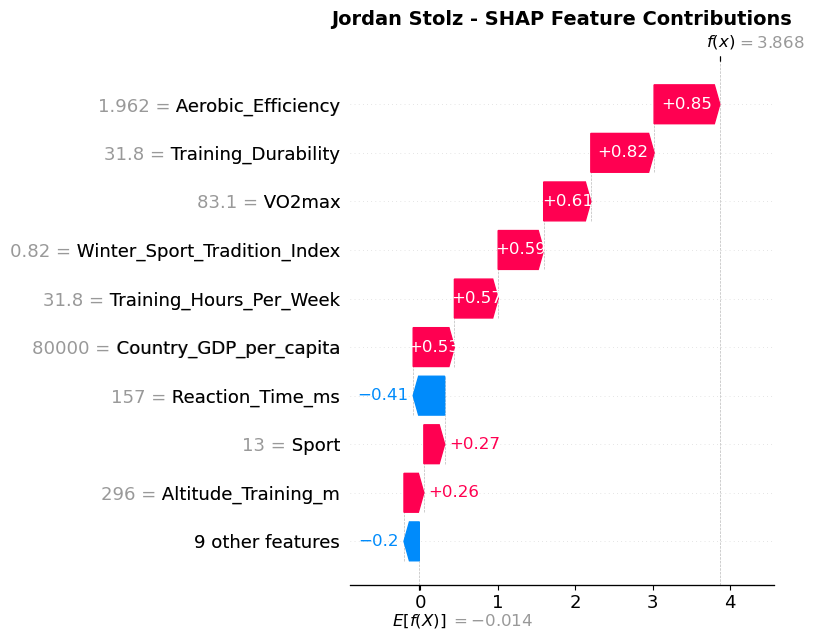



ATHLETE 2: Mikaela Shiffrin
Set: TRAIN
Predicted Probability: 0.967
Prediction: Medal
Actual: Gold
Correct: Yes


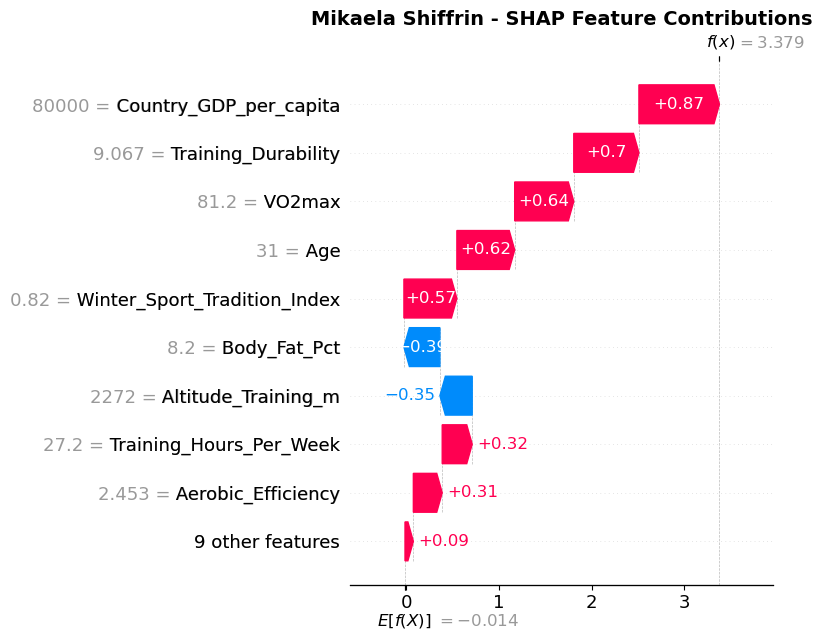



ATHLETE 3: Connor McDavid
Set: TEST
Predicted Probability: 0.316
Prediction: Medal
Actual: Silver
Correct: Yes


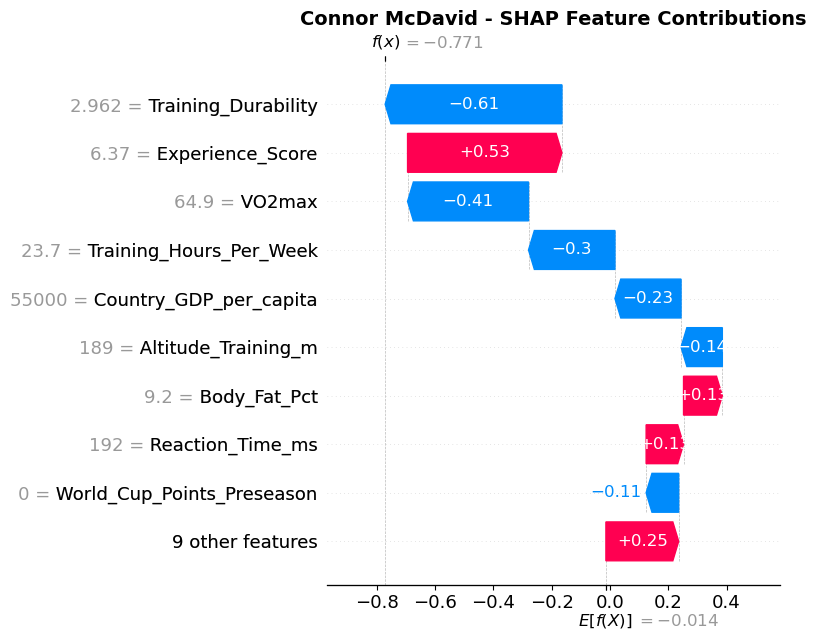



ATHLETE 4: Courtney Sarault
Set: TRAIN
Predicted Probability: 0.946
Prediction: Medal
Actual: Silver
Correct: Yes


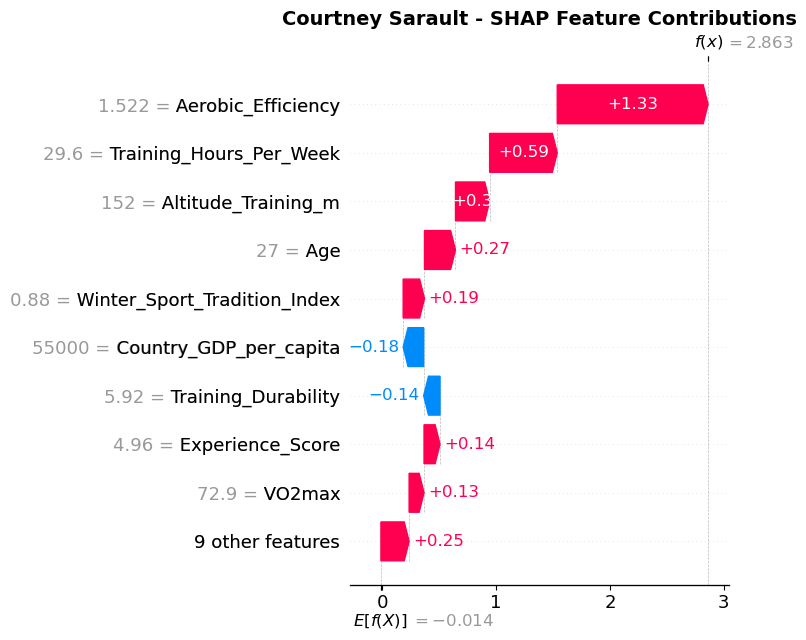



ATHLETE 5: Elana Meyers Taylor
Set: TEST
Predicted Probability: 0.786
Prediction: Medal
Actual: Gold
Correct: Yes


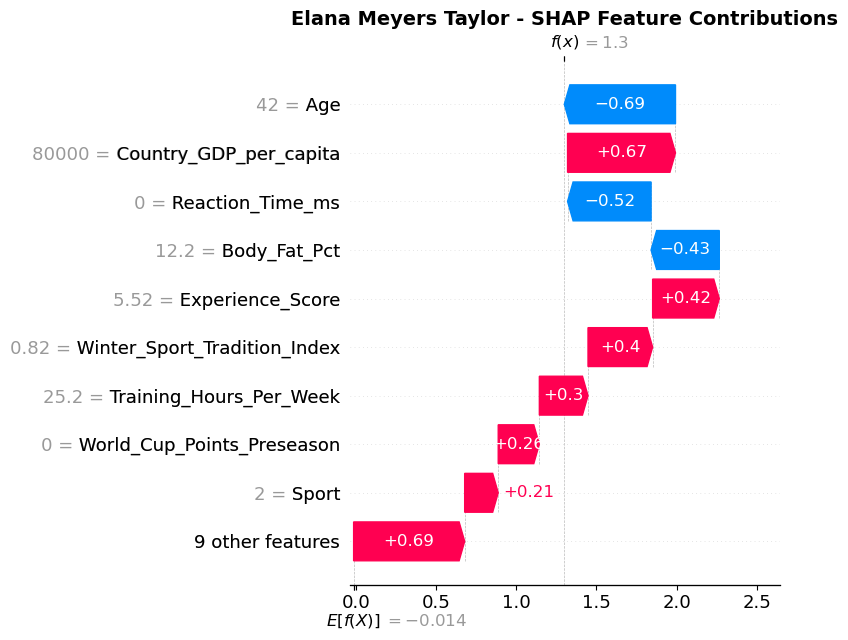



ATHLETE 6: Deanna Stellato-Dudek
Set: TEST
Predicted Probability: 0.199
Prediction: No Medal
Actual: nan
Correct: Yes


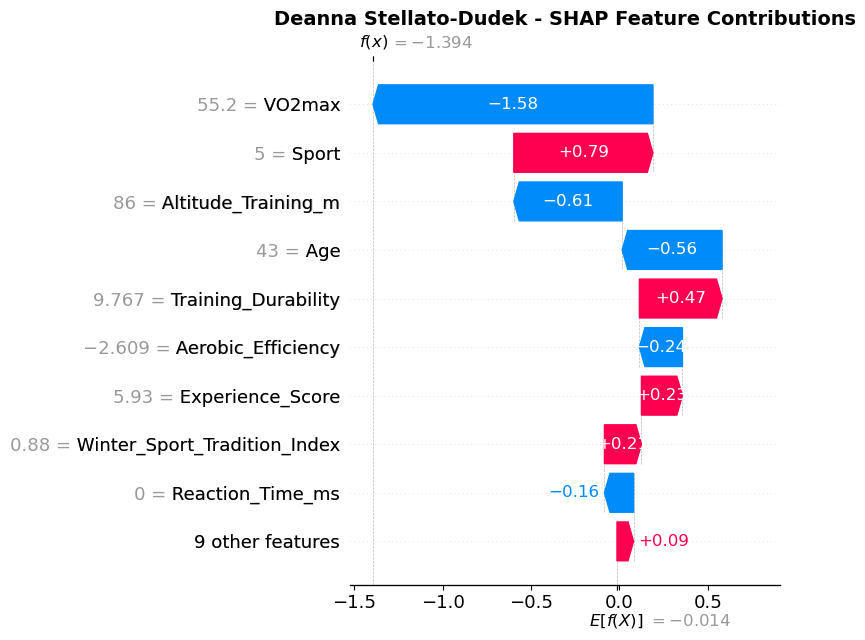



ATHLETE 7: Metodej Jilek
Set: TRAIN
Predicted Probability: 0.943
Prediction: Medal
Actual: Gold
Correct: Yes


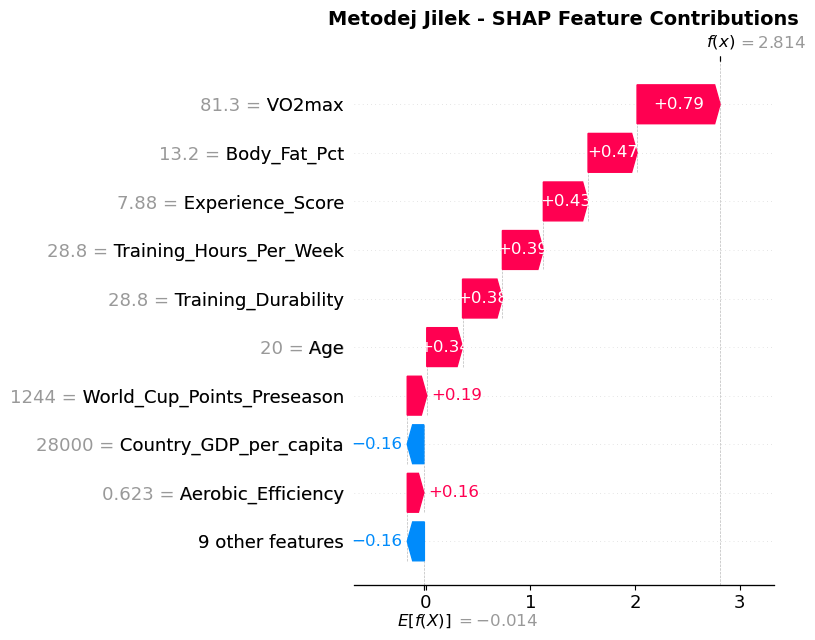

In [44]:
# Create individual waterfall plot for each athlete
for i, name in enumerate(athlete_names_list):
    print("="*80)
    print(f"ATHLETE {i+1}: {name}")
    print("="*80)
    
    # Get info
    actual = results_df.iloc[i]['Actual_Medal']
    prob = results_df.iloc[i]['Predicted_Probability']
    pred = results_df.iloc[i]['Predicted_Medal']
    athlete_idx = seven_athletes_indices[i]
    in_set = "TRAIN" if athlete_idx in X_train.index else "TEST"
    
    print(f"Set: {in_set}")
    print(f"Predicted Probability: {prob:.3f}")
    print(f"Prediction: {pred}")
    print(f"Actual: {actual}")
    print(f"Correct: {results_df.iloc[i]['Correct']}")
    
    # Create waterfall plot
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i],
            base_values=explainer.expected_value,
            data=seven_athletes_encoded.iloc[i],
            feature_names=feature_names
        ),
        max_display=10,
        show=False
    )
    plt.title(f"{name} - SHAP Feature Contributions", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_{i+1}_{name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n")